In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Veri Bilimi Ara Ödev

Veri seti: "e_ticaret_veri_seti.csv"

Yapılacaklar:

  1. Veri setini yükleyin ve ilk 10 satırı ile son 10 satırını ekrana yazdırın.

  2. Veri setinin satır sayısını, sütun sayısını ve tüm sütun isimlerini ekrana yazdırın.

  3. info() ve describe() çıktılarını alın. Ardından veri setindeki sayısal sütunları ve kategorik sütunları ayrı ayrı listeleyin.

  4. Her sütundaki eksik değer sayısını hesaplayın. Sonra eksik veri oranlarını yüzde olarak çıkarın ve eksik veri oranı en yüksek 5 sütunu yazdırın.

  5. En az bir eksik değer içeren satırları filtreleyin ve bu satırlardan ilk 20 tanesini ekrana yazdırın.

  6. indirim_orani ve musteri_puani sütunlarındaki eksik değerleri medyan ile doldurun. Doldurmadan önce ve sonra bu iki sütundaki eksik değer sayılarını karşılaştırın.

  7. odeme_turu ve musteri_tipi sütunlarındaki eksik değerleri mod ile doldurun. Daha sonra bu sütunlarda eksik değer kalıp kalmadığını kontrol edin.

  8. siparis_tarihi sütununu datetime tipine dönüştürün. Ardından bu sütundan siparis_yili, siparis_ayi, siparis_gunu ve haftanin_gunu adında 4 yeni sütun üretin ve ilk 10 satırını gösterin.

  9. Veri setindeki duplicate kayıt sayısını bulun. Duplicate kayıtları temizleyin ve temizlikten önce ve sonra veri setinin satır sayısını yazdırın.

  10. sehir sütunundaki benzersiz değerleri inceleyin. İstanbul, istanbul, Istanbul gibi aynı anlama gelen farklı yazımları tek bir standart biçime dönüştürün. Temizlikten önce ve sonra benzersiz değer sayılarını karşılaştırın.

  11. kategori sütunundaki tutarsız değerleri inceleyin. Örneğin Ev Yaşam, ev yaşam, ev&yaşam gibi farklı yazımları tek biçime dönüştürün. Temizlikten sonra value_counts() çıktısını yazdırın.

  12. Aşağıdaki koşullara uyan mantıksal olarak hatalı kayıtları bulun: birim_fiyat <= 0, toplam_tutar <= 0, teslimat_gunu < 0, musteri_puani > 5. Bu kayıtların sayısını yazdırın ve veri setinden çıkarın.

  13. birim_fiyat sütunu için IQR yöntemini kullanarak Q1, Q3, IQR, alt sınır ve üst sınır değerlerini hesaplayın. Sonra aykırı değer içeren kayıt sayısını yazdırın.

  14. toplam_tutar sütunu için histogram çizdirin ve box plot çizdirin. Ardından dağılım hakkında 2–3 cümlelik kısa bir yorum yazın.

  15. Aşağıdaki analizleri yapın:
      - kategori sütunu için value_counts() çıktısını yazdırın,
      
      - musteri_tipi sütunu için yüzde dağılımı hesaplayın, odeme_turu sütunu için count plot çizdirin,
     
      - birim_fiyat, toplam_tutar ve musteri_puani sütunlarının temel istatistiklerini çıkarın.
      
      - Son olarak şu iki soruya cevap verin:
        - Hangi kategori en yüksek ortalama toplam_tutar değerine sahip?

        - Hangi müşteri tipi en yüksek ortalama musteri_puani değerine sahip?

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# 1. Veri setini yükleyin ve ilk 10 satırı ile son 10 satırını ekrana yazdırın.

df = pd.read_csv("e_ticaret_veri_seti.csv")

# veri setinin yüklendiği drive dosyasından veri setinin dosya yolu kopyalanır
# ve read_csv() fonksiyonunun içine yazılarak veri setinin okunması sağlanır.

In [76]:
df.head(10)

# ilk 10 satır görüntülenmek istendiği için head() fonksiyonunun içine 10 yazılır.

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03
5,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94
6,SIP101351,MUS1011,2025-02-27 11:35:00,İstanbul,Marmara,Ofis,Mouse Pad,3,169.47,0.05,29.9,Havale/EFT,VIP,3.0,2.0,Evet,0.382,512.89
7,SIP101172,MUS1357,2024-07-22 13:26:00,Ankara,İç Anadolu,Ofis,Mekanik Klavye,3,2344.47,0.00,59.9,Kredi Kartı,Mevcut,3.0,4.0,Hayır,0.312,7093.31
8,SIP100779,MUS1354,2025-12-05 11:19:00,İstanbul,Marmara,Kitap,Python Notları,4,219.14,0.00,29.9,Kredi Kartı,Yeni,18.0,5.0,Evet,0.408,906.46
9,SIP100202,MUS1067,2024-05-11 22:53:00,Bursa,Marmara,Kozmetik,Güneş Kremi,2,424.40,0.00,29.9,Havale/EFT,Mevcut,3.0,1.0,Hayır,0.212,878.70


In [77]:
df.tail(10)

# son 10 satır görüntülenmek istendiği için tail() fonksiyonunun içine 10 yazılır.

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
1418,SIP100056,MUS1238,2024-04-19 20:27:00,Ankara,İç Anadolu,Kitap,Veri Bilimi 101,2,255.70,0.05,59.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.247,545.73
1419,SIP101279,MUS1149,2024-08-24 08:38:00,Ankara,İç Anadolu,Elektronik,Akıllı Saat,4,3074.80,0.15,39.9,Banka Kartı,Yeni,4.0,5.0,Hayır,0.414,10494.22
1420,SIP100920,MUS1425,2025-07-04 14:58:00,İzmir,Ege,Ev ve Yaşam,Masa Lambası,2,699.19,0.00,49.9,Banka Kartı,Yeni,2.0,4.0,Hayır,0.336,1448.28
1421,SIP100480,MUS1323,2024-06-20 20:34:00,Ankara,İç Anadolu,Elektronik,Kablosuz Kulaklık,1,1468.25,0.05,39.9,Banka Kartı,Mevcut,2.0,4.0,Hayır,0.275,1434.74
1422,SIP101222,MUS1440,2025-05-14 09:21:00,Bursa,Marmara,Spor,Dambıl Seti,1,1488.18,0.00,29.9,Kredi Kartı,Mevcut,3.0,4.0,Hayır,0.189,1518.08
1423,SIP101093,MUS1187,2024-06-08 20:42:00,İstanbul,Marmara,Spor,Yoga Matı,1,772.23,0.00,29.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.275,802.13
1424,SIP101193,MUS1297,2025-11-06 08:17:00,Gaziantep,Güneydoğu Anadolu,Spor,Suluk,2,187.03,0.00,59.9,Kredi Kartı,Yeni,2.0,4.0,Evet,0.243,433.96
1425,SIP101210,MUS1122,2025-03-07 09:07:00,NaN,Marmara,Elektronik,Webcam,4,894.47,0.10,49.9,Kredi Kartı,Mevcut,3.0,5.0,Hayır,0.355,3269.99
1426,SIP101060,MUS1189,2025-04-19 21:52:00,Kocaeli,Marmara,Kitap,Veri Bilimi 101,2,248.55,0.05,59.9,banka karti,Yeni,4.0,3.0,Hayır,0.373,532.14
1427,SIP100642,MUS1289,2024-09-22 16:36:00,Ankara,İç Anadolu,Kozmetik,Güneş Kremi,1,424.84,0.20,0.0,Dijital Cüzdan,Yeni,2.0,4.0,Hayır,0.317,339.87


In [78]:
# 2. Veri setinin satır sayısını, sütun sayısını ve tüm sütun isimlerini ekrana yazdırın.

# (satır sayısı, sütun sayısı) formatında bize veri setindeki satır ve sütun sayılarını verir
df.shape

(1428, 18)

In [79]:
# shape özelliğinin sıfırıncı indeksini alırsak sadece satır sayısını görüntüleyebiliriz.

satir_sayisi = df.shape[0]
satir_sayisi

1428

In [80]:
# shape özelliğinin birinci indeksini alırsak sadece sütun sayısını görüntüleyebiliriz.

sutun_sayisi = df.shape[1]
sutun_sayisi

18

In [81]:
# Her 14 sütunun ismini görmek istediğimiz için; yinelenebilir(iterable) değerleri özellikle döngüler içerisinde
# görüntüleyebilmemizi sağlayan enumerate() fonksiyonuyla birlikte bir for döngüsü yazarız, böylece her bir satırın
# isimlerini görebileceğimiz f-string yapısı yardımıyla yazdırabiliriz.


for i, sutun in enumerate(df.columns, start = 1):
  print(f"{i}, {sutun}")


1, siparis_id
2, musteri_id
3, siparis_tarihi
4, sehir
5, bolge
6, kategori
7, urun_adi
8, adet
9, birim_fiyat
10, indirim_orani
11, kargo_ucreti
12, odeme_turu
13, musteri_tipi
14, teslimat_gunu
15, musteri_puani
16, iade_durumu
17, kar_marji_orani
18, toplam_tutar


In [82]:
# 3. info() ve describe() çıktılarını alın. Ardından veri setindeki sayısal sütunları ve kategorik sütunları ayrı ayrı listeleyin.

# info() fonksiyonu; sütun isimlerini, veri tiplerini ve kayıp değerleri görebilmemizi sağlar.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   siparis_id       1428 non-null   object 
 1   musteri_id       1428 non-null   object 
 2   siparis_tarihi   1428 non-null   object 
 3   sehir            1403 non-null   object 
 4   bolge            1428 non-null   object 
 5   kategori         1428 non-null   object 
 6   urun_adi         1428 non-null   object 
 7   adet             1428 non-null   int64  
 8   birim_fiyat      1428 non-null   float64
 9   indirim_orani    1412 non-null   float64
 10  kargo_ucreti     1428 non-null   float64
 11  odeme_turu       1393 non-null   object 
 12  musteri_tipi     1386 non-null   object 
 13  teslimat_gunu    1400 non-null   float64
 14  musteri_puani    1372 non-null   float64
 15  iade_durumu      1428 non-null   object 
 16  kar_marji_orani  1428 non-null   float64
 17  toplam_tutar  

In [83]:
# describe() fonksiyonu, veri setinde bulunan her bir sayısal sütunun temel istatistik değerlerini görebilmemizi sağlar

# bu şekilde o sayısal sütundaki; veri sayısını(count), verilerin ortalamasını(mean), verilerin standart sapmasını, minimum değerini,
# ilk çeyrek değerini(%25 (Q1)), orta değerini (%50), son çeyrek değerini (%75(Q3)) ve maksimum değerini görüntüleyebiliriz.
df.describe()

,adet,birim_fiyat,indirim_orani,kargo_ucreti,teslimat_gunu,musteri_puani,kar_marji_orani,toplam_tutar
count,1428.000000,1428.000000,1412.000000,1428.000000,1400.000000,1372.000000,1428.000000,1428.000000
mean,2.136555,658.477654,0.052054,39.725140,3.370714,4.002187,0.302799,1370.590336
std,2.015770,1042.414639,0.060115,14.185017,1.825990,1.096707,0.069795,2961.689500
min,1.000000,93.110000,0.000000,0.000000,1.000000,0.000000,0.180000,89.680000
25%,1.000000,199.185000,0.000000,29.900000,2.000000,3.000000,0.244750,323.855000
50%,2.000000,287.120000,0.050000,39.900000,3.000000,4.000000,0.305000,669.135000
75%,3.000000,819.177500,0.100000,49.900000,4.000000,5.000000,0.362000,1390.950000
max,38.000000,18145.230000,0.200000,59.900000,31.000000,7.000000,0.420000,63870.200000


In [84]:
# Veri setinde bulunan veri tiplerini sayısal ve kategorik olarak ayırabilmek için önce veri setindeki tüm veri tiplerini
# görüntüler sonrasında gerekli ayırma işlemlerini sağlarız

df.dtypes  # dtypes özelliği, çalıştığımız veri setindeki veri tiplerini görüntülememizi sağlar

,0
siparis_id,object
musteri_id,object
siparis_tarihi,object
sehir,object
bolge,object
kategori,object
urun_adi,object
adet,int64
birim_fiyat,float64
indirim_orani,float64


In [85]:
# Sayısal ve kategorik sütunların hangileri olduğunu görebilmemizle birlikte gerekli işlemleri yaparak ayırabiliriz

# Sayısal sütunlar: float64, int64

sayisal_sutunlar = df.select_dtypes(include=["int64", "float64"]).columns
sayisal_sutunlar


Index(['adet', 'birim_fiyat', 'indirim_orani', 'kargo_ucreti', 'teslimat_gunu',
       'musteri_puani', 'kar_marji_orani', 'toplam_tutar'],
      dtype='object')

In [86]:
# Kategorik sütunlar: object (string yapıları)

kategorik_sutunlar = df.select_dtypes(include=["object"]).columns
kategorik_sutunlar

Index(['siparis_id', 'musteri_id', 'siparis_tarihi', 'sehir', 'bolge',
       'kategori', 'urun_adi', 'odeme_turu', 'musteri_tipi', 'iade_durumu'],
      dtype='object')

In [87]:
# 4. Her sütundaki eksik değer sayısını hesaplayın.

df.isnull().sum()


,0
siparis_id,0
musteri_id,0
siparis_tarihi,0
sehir,25
bolge,0
kategori,0
urun_adi,0
adet,0
birim_fiyat,0
indirim_orani,16


In [88]:
#  Sonra eksik veri oranlarını yüzde olarak çıkarın
eksik_sayilar = df.isnull().sum()
eksik_oranlar = 100*(eksik_sayilar/len(df))
eksik_oranlar

,0
siparis_id,0.000000
musteri_id,0.000000
siparis_tarihi,0.000000
sehir,1.750700
bolge,0.000000
kategori,0.000000
urun_adi,0.000000
adet,0.000000
birim_fiyat,0.000000
indirim_orani,1.120448


In [89]:
# eksik veri oranı en yüksek 5 sütunu yazdırın.

eksik_oranlar.sort_values(ascending=False).head(5)

,0
musteri_puani,3.921569
musteri_tipi,2.941176
odeme_turu,2.450980
teslimat_gunu,1.960784
sehir,1.750700


In [90]:
# 5. En az bir eksik değer içeren satırları filtreleyin ve bu satırlardan ilk 20 tanesini ekrana yazdırın.
eksik_degerli_satirlar = df[df.isnull().any(axis=1)]
eksik_degerli_satirlar.head(20)


,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
19,SIP100677,MUS1148,2024-07-11 16:24:00,Adana,Akdeniz,Spor,Dambıl Seti,4,1517.65,0.00,29.9,Kapıda Ödeme,Mevcut,3.0,NaN,Hayır,0.311,6100.50
33,SIP101126,MUS1406,2024-09-11 20:05:00,Mersin,Akdeniz,Elektronik,Bluetooth Hoparlör,1,1159.89,0.10,39.9,Kredi Kartı,NaN,2.0,4.0,Hayır,0.204,1083.80
50,SIP101040,MUS1386,2025-04-01 09:30:00,Trabzon,Karadeniz,Spor,Dambıl Seti,1,1554.15,0.00,49.9,Banka Kartı,NaN,4.0,5.0,Hayır,0.217,1604.05
60,SIP100890,MUS1271,2024-11-07 19:47:00,İzmir,Ege,Kitap,Girişimcilik,4,216.38,NaN,49.9,Kredi Kartı,Yeni,1.0,3.0,Hayır,0.199,915.42
61,SIP101317,MUS1060,2024-09-05 20:49:00,NaN,Akdeniz,Ev ve Yaşam,Saklama Kutusu,1,233.63,0.10,29.9,Dijital Cüzdan,Yeni,5.0,2.0,Hayır,0.385,240.17
70,SIP100715,MUS1033,2024-11-10 21:50:00,İstanbul,Marmara,Ev ve Yaşam,Termos,1,552.05,0.00,39.9,NaN,Mevcut,2.0,3.0,Hayır,0.185,591.95
82,SIP100807,MUS1431,2025-01-07 14:12:00,Ankara,İç Anadolu,Kozmetik,Güneş Kremi,1,451.28,0.00,49.9,Kredi Kartı,NaN,4.0,5.0,Hayır,0.315,501.18
84,SIP100679,MUS1310,2024-05-20 18:51:00,İzmir,Ege,Ev ve Yaşam,Termos,2,477.62,0.00,49.9,Kredi Kartı,Mevcut,NaN,4.0,Hayır,0.323,1005.14
86,SIP101071,MUS1131,2024-09-18 12:24:00,NaN,İç Anadolu,Elektronik,Powerbank,1,816.74,0.00,39.9,Banka Kartı,Yeni,3.0,5.0,Hayır,0.301,856.64
92,SIP101366,MUS1347,2025-03-04 14:00:00,Bursa,Marmara,Ev ve Yaşam,Organizer,1,272.40,0.00,29.9,Kredi Kartı,Mevcut,1.0,NaN,Hayır,0.212,302.30


In [91]:
# 6. indirim_orani ve musteri_puani sütunlarındaki eksik değerleri medyan ile doldurun.
# Doldurmadan önce ve sonra bu iki sütundaki eksik değer sayılarını karşılaştırın.

# İşlem öncesi eksik değer sayılarını görüntülüyoruz
print("Doldurmadan Önceki Eksik Değer Sayıları:")
print(df[['indirim_orani', 'musteri_puani']].isnull().sum())


Doldurmadan Önceki Eksik Değer Sayıları:
indirim_orani    16
musteri_puani    56
dtype: int64


In [92]:
# Eksik değerleri sütunların kendi medyan (ortanca) değerleri ile dolduruyoruz.
# inplace=True kullanımı Pandas'ın yeni sürümlerinde yavaş yavaş kaldırıldığı için
# değişkenin kendisine atama yapmak daha güvenli ve modern bir yaklaşımdır.

df['indirim_orani'] = df['indirim_orani'].fillna(df['indirim_orani'].median())
df['musteri_puani'] = df['musteri_puani'].fillna(df['musteri_puani'].median())

# İşlem sonrası eksik değer kalıp kalmadığını kontrol ediyoruz

print("\nMedyan ile Doldurulduktan Sonraki Eksik Değer Sayıları:")
print(df[['indirim_orani', 'musteri_puani']].isnull().sum())


Medyan ile Doldurulduktan Sonraki Eksik Değer Sayıları:
indirim_orani    0
musteri_puani    0
dtype: int64


In [93]:
# 7. odeme_turu ve musteri_tipi sütunlarındaki eksik değerleri mod ile doldurun.
# Daha sonra bu sütunlarda eksik değer kalıp kalmadığını kontrol edin.

# Mod (en çok tekrar eden değer) ile doldurma işlemi.
# mode() fonksiyonu birden fazla tepe değer olabilme ihtimaline karşı bir Seri (Series) döndürür.
# Bu yüzden indeksleme yaparak [0] ile en baştaki (en yaygın) değeri seçmemiz gerekir.

df['odeme_turu'] = df['odeme_turu'].fillna(df['odeme_turu'].mode()[0])
df['musteri_tipi'] = df['musteri_tipi'].fillna(df['musteri_tipi'].mode()[0])

# İşlem sonrası eksik değer kalıp kalmadığını kontrol ediyoruz

print("Mod ile Doldurulduktan Sonraki Eksik Değer Sayıları:")
print(df[['odeme_turu', 'musteri_tipi']].isnull().sum())

Mod ile Doldurulduktan Sonraki Eksik Değer Sayıları:
odeme_turu      0
musteri_tipi    0
dtype: int64


In [94]:
# 8. siparis_tarihi sütununu datetime tipine dönüştürün.
# Ardından bu sütundan siparis_yili, siparis_ayi, siparis_gunu ve haftanin_gunu adında 4 yeni sütun üretin.

# İlk olarak 'siparis_tarihi' sütununun veri tipini datetime'a dönüştürüyoruz.

df['siparis_tarihi'] = pd.to_datetime(df['siparis_tarihi'])
df["siparis_tarihi"].dtype

dtype('<M8[ns]')

In [95]:
# Datetime özelliğinin (.dt) alt fonksiyonlarını kullanarak yeni sütunlarımızı üretiyoruz.

df['siparis_yili'] = df['siparis_tarihi'].dt.year
df['siparis_ayi'] = df['siparis_tarihi'].dt.month
df['siparis_gunu'] = df['siparis_tarihi'].dt.day
df['haftanin_gunu'] = df['siparis_tarihi'].dt.day_name()  # İngilizce gün isimlerini getirir (Monday, Tuesday vb.)

# Sadece bu yeni ürettiğimiz sütunları ve orijinal tarih sütununu seçip ilk 10 satırı görüntülüyoruz.

print("Yeni üretilen tarih sütunları:")
df[['siparis_tarihi', 'siparis_yili', 'siparis_ayi', 'siparis_gunu', 'haftanin_gunu']].head(10)

Yeni üretilen tarih sütunları:


,siparis_tarihi,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,2024-01-13 17:06:00,2024,1,13,Saturday
1,2025-03-17 21:13:00,2025,3,17,Monday
2,2025-06-03 12:42:00,2025,6,3,Tuesday
3,2024-08-10 15:13:00,2024,8,10,Saturday
4,2024-08-19 08:24:00,2024,8,19,Monday
5,2025-08-09 08:42:00,2025,8,9,Saturday
6,2025-02-27 11:35:00,2025,2,27,Thursday
7,2024-07-22 13:26:00,2024,7,22,Monday
8,2025-12-05 11:19:00,2025,12,5,Friday
9,2024-05-11 22:53:00,2024,5,11,Saturday


In [96]:
# 9. Veri setindeki duplicate kayıt sayısını bulun. Duplicate kayıtları temizleyin
# ve temizlikten önce ve sonra veri setinin satır sayısını yazdırın.

# Temizlik öncesi satır sayısını ve tekrarlayan kayıt sayısını buluyoruz.

satir_sayisi_once = df.shape[0]
tekrar_sayisi = df.duplicated().sum()

print(f"Temizlikten Önceki Satır Sayısı: {satir_sayisi_once}")
print(f"Tespit Edilen Duplicate (Tekrarlayan) Kayıt Sayısı: {tekrar_sayisi}")

Temizlikten Önceki Satır Sayısı: 1428
Tespit Edilen Duplicate (Tekrarlayan) Kayıt Sayısı: 28


In [97]:
# drop_duplicates() fonksiyonu ile tamamen aynı olan satırları veri setinden siliyoruz.
df = df.drop_duplicates()

# Temizlik sonrası yeni satır sayısını kontrol ediyoruz.
satir_sayisi_sonra = df.shape[0]
print(f"\nTemizlikten Sonraki Satır Sayısı: {satir_sayisi_sonra}")


Temizlikten Sonraki Satır Sayısı: 1400


In [98]:
# 10. sehir sütunundaki benzersiz değerleri inceleyin. İstanbul, istanbul, Istanbul gibi aynı anlama gelen
# farklı yazımları tek bir standart biçime dönüştürün. Temizlikten önce ve sonra benzersiz değer sayılarını karşılaştırın.

# İşlem öncesi benzersiz şehir sayısını ve değerlerini listeliyoruz.
# nunique() -> number of unique (benzersiz sayı), unique() -> benzersiz değerlerin kendisi

print("Temizlikten Önceki Benzersiz Şehir Sayısı:", df['sehir'].nunique())
print("Önceki Benzersiz Değerler:", df['sehir'].unique())

Temizlikten Önceki Benzersiz Şehir Sayısı: 19
Önceki Benzersiz Değerler: ['İstanbul' 'Gaziantep' 'Kayseri' 'Antalya' 'Konya' 'Ankara' 'Bursa'
 'Trabzon' 'Adana' 'Mersin' 'Kocaeli' 'İzmir' 'Eskişehir' 'Samsun' nan
 'istanbul' 'ankara' 'Istanbul' 'gaziantep' 'Izmir']


In [99]:
# Standartlaştırma işlemi:
# 1. str.strip(): Verinin başında veya sonundaki gizli boşlukları siler.
# 2. str.title(): Kelimelerin ilk harfini büyük, diğerlerini küçük yapar (Standart başlık formatı).
df['sehir'] = df['sehir'].str.strip().str.title()

# Türkçe karakter kaynaklı şehir büyük harfleri düzeltmesi:

duzeltmeler = {
    'Istanbul': 'İstanbul',
    'Izmir': 'İzmir'
}
df['sehir'] = df['sehir'].replace(duzeltmeler)

# İşlem sonrası durum kontrolü:

print("\nTemizlikten Sonraki Benzersiz Şehir Sayısı:", df['sehir'].nunique())
print("Sonraki Benzersiz Değerler:", df['sehir'].unique())


Temizlikten Sonraki Benzersiz Şehir Sayısı: 14
Sonraki Benzersiz Değerler: ['İstanbul' 'Gaziantep' 'Kayseri' 'Antalya' 'Konya' 'Ankara' 'Bursa'
 'Trabzon' 'Adana' 'Mersin' 'Kocaeli' 'İzmir' 'Eskişehir' 'Samsun' nan]


In [100]:
# 11. kategori sütunundaki tutarsız değerleri inceleyin.
# Örneğin Ev Yaşam, ev yaşam, ev&yaşam gibi farklı yazımları tek biçime dönüştürün.
# Temizlikten sonra value_counts() çıktısını yazdırın.

# str.replace() ile aradaki '&' işaretini boşlukla değiştiriyoruz.
# Ardından str.strip() ile kenarlardaki boşlukları alıp, str.title() ile baş harflerini büyütüyoruz.

df['kategori'] = df['kategori'].str.replace('&', ' ').str.strip().str.title()

# Temizlik işlemi sonrasında kategorilerin güncel dağılımını (frekanslarını) görüntülüyoruz.

print("Temizlenmiş Kategori Dağılımı:")
print(df['kategori'].value_counts())

Temizlenmiş Kategori Dağılımı:
kategori
Kitap          253
Elektronik     241
Spor           235
Ofis           230
Kozmetik       221
Ev Ve Yaşam    215
Kozmetık         4
Ev Yaşam         1
Name: count, dtype: int64


In [101]:
# 12. Aşağıdaki koşullara uyan mantıksal olarak hatalı kayıtları bulun:
# birim_fiyat <= 0, toplam_tutar <= 0, teslimat_gunu < 0, musteri_puani > 5.
# Bu kayıtların sayısını yazdırın ve veri setinden çıkarın.

# Hatalı kayıtları tespit etmek için koşullarımızı (filtre maskesi) oluşturuyoruz.
# Her bir koşulu parantez içine alıp VEYA (|) operatörü ile bağlıyoruz.
hatali_maske = (df['birim_fiyat'] <= 0) | \
               (df['toplam_tutar'] <= 0) | \
               (df['teslimat_gunu'] < 0) | \
               (df['musteri_puani'] > 5)

# Hatalı kayıtları DataFrame üzerinden filtreleyip sayısını buluyoruz.
hatali_kayitlar = df[hatali_maske]
print(f"Tespit Edilen Hatalı Kayıt Sayısı: {len(hatali_kayitlar)}")

Tespit Edilen Hatalı Kayıt Sayısı: 2


In [102]:
# Hatalı kayıtları veri setinden çıkarıyoruz.
# (Dalga işareti ~ "değili/tersi" anlamına gelir, yani hatalı OLMAYANLARI df'te tutuyoruz)
df = df[~hatali_maske]

# İşlem sonrası veri setinin son satır sayısını kontrol ediyoruz.
print(f"Hatalı Kayıtlar Silindikten Sonraki Satır Sayısı: {df.shape[0]}")

Hatalı Kayıtlar Silindikten Sonraki Satır Sayısı: 1398


In [103]:
# 13. birim_fiyat sütunu için IQR yöntemini kullanarak Q1, Q3, IQR, alt sınır ve üst sınır değerlerini hesaplayın.
# Sonra aykırı değer içeren kayıt sayısını yazdırın.

# 1. Çeyreklik (Q1 - %25) ve 3. Çeyreklik (Q3 - %75) değerlerini hesaplıyoruz

Q1 = df['birim_fiyat'].quantile(0.25)
Q3 = df['birim_fiyat'].quantile(0.75)

# Çeyrekler Açıklığı (IQR)

IQR = Q3 - Q1

# Alt ve üst sınırların belirlenmesi (Veri biliminde standart olarak 1.5 katsayısı kullanılır)

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Hesaplanan istatistiksel sınırları yazdırıyoruz

print(f"Q1 (1. Çeyreklik): {Q1}")
print(f"Q3 (3. Çeyreklik): {Q3}")
print(f"IQR: {IQR}")
print(f"Alt Sınır: {alt_sinir}")
print(f"Üst Sınır: {ust_sinir}")

# Alt sınırın altında KÜÇÜK veya üst sınırın üstünde BÜYÜK olan değerleri filtreliyoruz
aykiri_degerler = df[(df['birim_fiyat'] < alt_sinir) | (df['birim_fiyat'] > ust_sinir)]

print(f"\nTespit Edilen Aykırı Değer İçeren Kayıt Sayısı: {len(aykiri_degerler)}")

Q1 (1. Çeyreklik): 198.85500000000002
Q3 (3. Çeyreklik): 817.335
IQR: 618.48
Alt Sınır: -728.865
Üst Sınır: 1745.055

Tespit Edilen Aykırı Değer İçeren Kayıt Sayısı: 92


/tmp/ipykernel_1610/2697590907.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='kategori', y='toplam_tutar', palette='Set2')


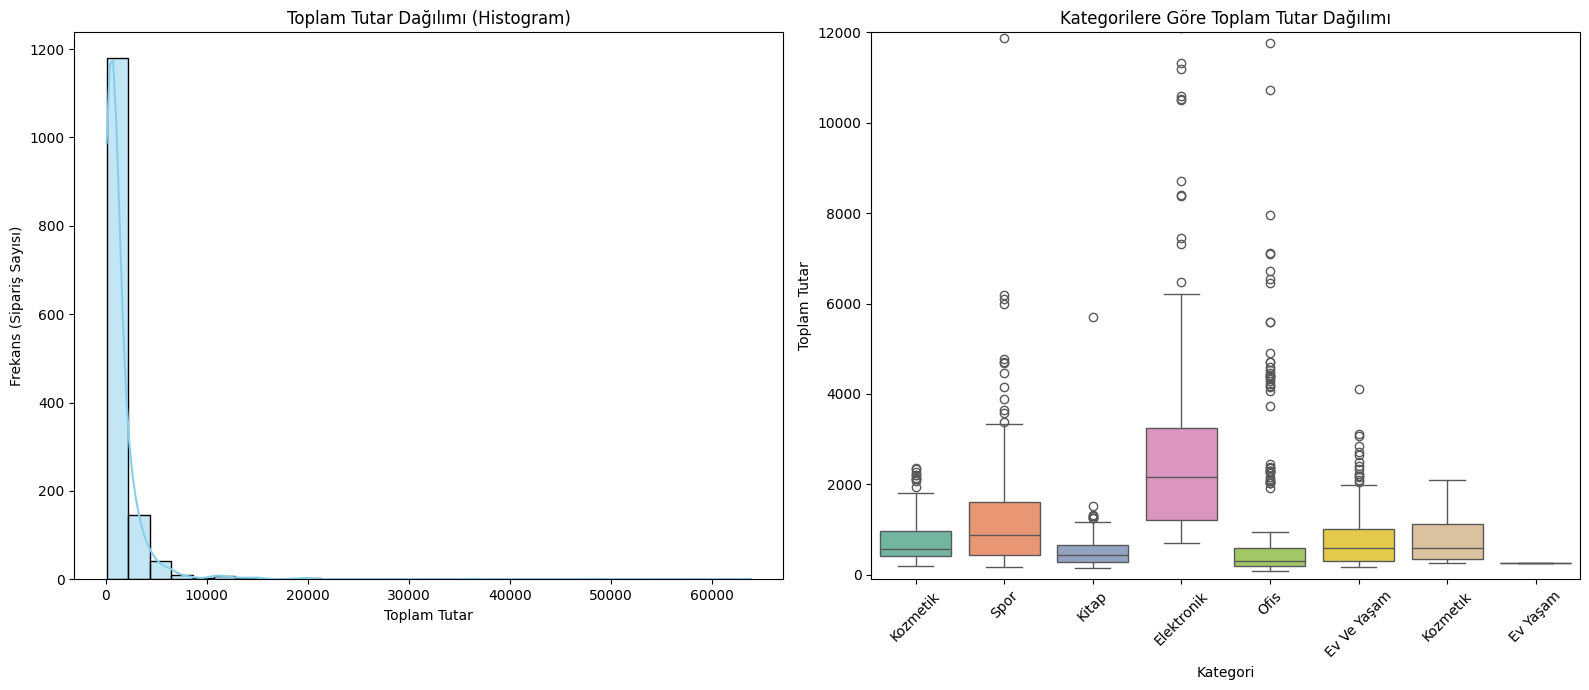

In [104]:
# 14. toplam_tutar sütunu için histogram çizdirin ve box plot çizdirin.

# Grafikleri yan yana daha net görebilmek için boyutlandırıyoruz

plt.figure(figsize=(16, 7))

# 1. Grafik: Histogram (Dağılımın şeklini görmek için)

plt.subplot(1, 2, 1)
sns.histplot(df['toplam_tutar'], bins=30, kde=True, color='skyblue')
plt.title('Toplam Tutar Dağılımı (Histogram)')
plt.xlabel('Toplam Tutar')
plt.ylabel('Frekans (Sipariş Sayısı)')

# 2. Grafik: Box Plot (Kategorilere göre)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='kategori', y='toplam_tutar', palette='Set2')
plt.title('Kategorilere Göre Toplam Tutar Dağılımı')
plt.xlabel('Kategori')
plt.ylabel('Toplam Tutar')
plt.xticks(rotation=45)

# 60.000'lik uç değerler grafiği ezmesin diye y eksenini 0 ile 12.000 arasında sınırlandırıyoruz (Zoom in)
plt.ylim(-100, 12000)

# Grafikleri göster

plt.tight_layout()
plt.show()

#### Histogram Grafiği:

Histogram grafiğine baktığımızda dağılımın sağa çarpık (right-skewed) olduğunu görüyoruz; yani siparişlerin büyük çoğunluğu düşük/orta tutarlarda toplanmışken, frekansı düşük ancak tutarı çok yüksek olan az sayıda sipariş kuyruğu sağa doğru uzatıyor.


#### Box Plot Grafiği:

Box plot üzerindeki sağ tarafa yığılmış noktalar da bu çok yüksek tutarlı harcamaların genel dağılıma göre aykırı değer (outlier) eğilimi gösterdiğini doğrulamaktadır.

In [105]:
# 15. Aşağıdaki analizleri yapın ve iki soruyu cevaplayın.

print("--- 1. Kategori Dağılımı ---")
kategori_dagilimi = df['kategori'].value_counts()
kategori_dagilimi.index.name = None
print(kategori_dagilimi.to_string())

--- 1. Kategori Dağılımı ---
Kitap          253
Elektronik     241
Spor           235
Ofis           230
Kozmetik       219
Ev Ve Yaşam    215
Kozmetık         4
Ev Yaşam         1


In [106]:
print("\n--- 2. Müşteri Tipi Yüzde Dağılımı (%) ---")
# normalize=True bize oranı verir, 100 ile çarparak yüzde formuna getiriyoruz
musteri_tipi_yuzde = df['musteri_tipi'].value_counts(normalize=True) * 100
print(musteri_tipi_yuzde.round(2).to_string())



--- 2. Müşteri Tipi Yüzde Dağılımı (%) ---
musteri_tipi
Mevcut    49.50
Yeni      36.19
VIP       11.30
mevcut     1.65
yeni       0.93
vip        0.29
Vip        0.14


In [107]:

print("\n--- 3. Temel İstatistikler ---")
# İstenen 3 sayısal sütunun özet istatistiklerini (describe) alıyoruz
istatistikler = df[['birim_fiyat', 'toplam_tutar', 'musteri_puani']].describe().round(2)
print(istatistikler)


--- 3. Temel İstatistikler ---
       birim_fiyat  toplam_tutar  musteri_puani
count      1398.00       1398.00        1398.00
mean        660.71       1377.93           4.00
std        1051.01       2988.04           1.07
min          93.11         89.68           0.00
25%         198.86        327.19           4.00
50%         287.12        670.96           4.00
75%         817.34       1393.25           5.00
max       18145.23      63870.20           5.00


In [108]:
print("\n--- 4. Soruların Cevapları ---")
# Hangi kategori en yüksek ortalama toplam_tutar değerine sahip?
en_yuksek_kategori = df.groupby('kategori')['toplam_tutar'].mean().idxmax()
en_yuksek_tutar = df.groupby('kategori')['toplam_tutar'].mean().max()
print(f"Cevap 1: En yüksek ortalama toplam tutara sahip kategori '{en_yuksek_kategori}' (Ortalama: {en_yuksek_tutar:.2f} TL)")

# Hangi müşteri tipi en yüksek ortalama musteri_puani değerine sahip?
en_yuksek_musteri = df.groupby('musteri_tipi')['musteri_puani'].mean().idxmax()
en_yuksek_puan = df.groupby('musteri_tipi')['musteri_puani'].mean().max()
print(f"Cevap 2: En yüksek ortalama müşteri puanına sahip müşteri tipi '{en_yuksek_musteri}' (Ortalama Puan: {en_yuksek_puan:.2f})")


--- 4. Soruların Cevapları ---
Cevap 1: En yüksek ortalama toplam tutara sahip kategori 'Elektronik' (Ortalama: 3178.38 TL)
Cevap 2: En yüksek ortalama müşteri puanına sahip müşteri tipi 'vip' (Ortalama Puan: 4.50)


/tmp/ipykernel_1610/801668213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='odeme_turu', palette='viridis')


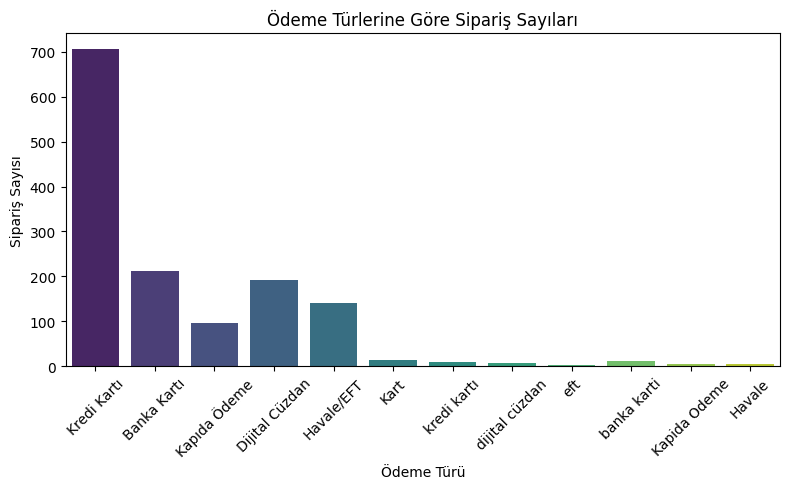

In [109]:
# 5. Ödeme Türü Count Plot (Grafik tuvalini kodun sonunda oluşturuyoruz)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='odeme_turu', palette='viridis')
plt.title('Ödeme Türlerine Göre Sipariş Sayıları')
plt.xlabel('Ödeme Türü')
plt.ylabel('Sipariş Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()